# Cross-match Blue Jay galaxies with A3COSMOS

Compare the two catalogues by matching the sources

In [12]:
from astropy.io import fits
from astropy.table import Table, join, hstack
from astropy.coordinates import SkyCoord, Angle
from astropy.wcs import WCS
from astropy.utils.data import download_file
import astropy.constants as const
from astropy import units as u

import numpy as np
import os
import sys
import matplotlib as mpl
import cmasher as cmr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import shapely
from shapely import Point, Polygon

import warnings
warnings.filterwarnings('ignore')

import pandas as pd

# cosmology
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)


CACHE_DOWNLOADS = True

import astropy

print(f'astropy version: {astropy.__version__}')

import grizli
from grizli import utils

print(f'grizli version: {grizli.__version__}')

astropy version: 7.2.0
grizli version: 1.13.9


In [11]:

# Load the prior catalogue
prior_path = 'A-COSMOS_prior_v20250312_Gaussian_with_meta_corrected_within_Pbcor_0.1_to_publish.fits'
prior_cat = fits.open(prior_path)[1].data
prior_cat = Table(prior_cat)

print(prior_cat.columns)

# Load the Blue Jay source catalogue
bluejay_path = 'cat_targets.fits'
my_cat = fits.open(bluejay_path)[1].data
my_cat = Table(my_cat)

# Rename columns for cross-matching
my_cat.rename_column('id', 'ID')
my_cat.rename_column('ra', 'RA')
my_cat.rename_column('dec', 'Dec')

# Filter the prior catalogue to ensure detections are reliable and have valid size estimates
neg_flux = prior_cat['Total_flux_pbcor'] < 0
lower = prior_cat['Flag_size_lower_boundary']
upper = prior_cat['Flag_size_upper_boundary']
initial = prior_cat['Flag_size_initial_guess']
zero_flux = prior_cat['Flag_zero_galfit_flux_error']
zero_size = prior_cat['Flag_zero_galfit_size_error']

# Apply quality flagging
alma_cat = prior_cat[
    (neg_flux == False) &
    (lower == False) &
    (upper == False) &
    (initial == False) &
    (zero_flux == False) &
    (zero_size == False)
]

print(f'{len(alma_cat)} out of {len(prior_cat)} sources in the prior catalogue after quality filtering.')

# Keep only the IDs of galaxies that have MIRI photometry
miri_path = '/Users/benjamincollins/University/master/Red_Cardinal/photometry/phot_tables/fits/Phot_Table_MIRI.fits'

miri_table = Table.read(miri_path, format='fits')
galaxy_ids = miri_table['ID']

# Filter out Blue Jay galaxies that are not in the MIRI table
source_cat_miri = my_cat[np.isin(my_cat['ID'], galaxy_ids)]

print(len(source_cat_miri), "galaxies in Blue Jay catalogue after filtering for MIRI photometry.")

# Build coordinates
coords_bluejay = SkyCoord(ra=source_cat_miri['RA']*u.deg, dec=source_cat_miri['Dec']*u.deg)
coords_cosmos = SkyCoord(ra=alma_cat['RA']*u.deg, dec=alma_cat['Dec']*u.deg)

# Match (within 0.3 arcsec, for instance)
idx, d2d, _ = coords_bluejay.match_to_catalog_sky(coords_cosmos)
match_mask = d2d < 0.3 * u.arcsec

print(f"Number of matches with Blue Jay: {np.sum(match_mask)}")

matched_ids = set(source_cat_miri['ID'][match_mask])
print(list(matched_ids))

cosmos_ids = set(alma_cat['ID'][idx[match_mask]])
print(list(cosmos_ids))

<TableColumns names=('ID','RA','Dec','Total_flux_pbcor','E_Total_flux_pbcor','E_Total_flux_sim_pbcor','Pbcor','Pb_corr_pb_image','Pb_corr_equation','Peak_flux','Image_file','Image_cutout','Obs_wavelength','Primary_beam','RMS_noise','Maj_beam','Min_beam','PA_beam','Galfit_reduced_chi_square','Flag_size_lower_boundary','Flag_size_upper_boundary','Flag_size_initial_guess','Flag_zero_galfit_flux_error','Flag_zero_galfit_size_error')>
2226 out of 341803 sources in the prior catalogue after quality filtering.
111 galaxies in Blue Jay catalogue after filtering for MIRI photometry.
Number of matches with Blue Jay: 4
[np.int64(8280), np.int64(18252), np.int64(21165), np.int64(13103)]
[np.int32(320337), np.int32(765691), np.int32(892054), np.int32(313094)]


Okay now let's try and be reasonable here.

Ideally, we want the data from
- Blue Jay source catalogue (ID, Ra, Dec, z_spec)
- Blue Jay HST/NIRCam photometry (ID, FXXXW_flux, FXXXW_flux_err, Aperture params)
- Blue Jay MIRI photometry (ID, FXXXW_flux, FXXXW_flux_err, Aperture params)
- A3COSMOS ALMA observations (ID_COSMOS, Ra_COSMOS, Dec_COSMOS, Total_flux_pbcor, E_Total_flux_pbcor, E_Total_flux_sim_pbcor and all the rest)

In [ ]:
miri_matched = miri_table[match_mask]
miri_matched.rename_column('ID', 'ID_3DHST')
alma_matched = alma_cat[idx[match_mask]]

print(alma_matched['RA'], alma_matched['Dec'])
alma_matched.rename_column('ID', 'ID_COSMOS')

sky_matched = hstack([alma_matched, miri_matched])

print(sky_matched.columns)


     RA    
-----------
150.0985353
150.0880263
150.0864431
150.1054047    Dec   
---------
2.3653718
2.3951005
2.2643185
2.3128168
ID_3DHST
--------
    9871
   16874
   20720
   12332      RA    
-----------
150.0985353
150.0880263
150.0864431
150.1054047    Dec   
---------
2.3653718
2.3951005
2.2643185
2.3128168 Obs_wavelength
--------------
       872.771
       872.804
       1286.74
       872.663
<TableColumns names=('ID_COSMOS','RA','Dec','Total_flux_pbcor','E_Total_flux_pbcor','E_Total_flux_sim_pbcor','Pbcor','Pb_corr_pb_image','Pb_corr_equation','Peak_flux','Image_file','Image_cutout','Obs_wavelength','Primary_beam','RMS_noise','Maj_beam','Min_beam','PA_beam','Galfit_reduced_chi_square','Flag_size_lower_boundary','Flag_size_upper_boundary','Flag_size_initial_guess','Flag_zero_galfit_flux_error','Flag_zero_galfit_size_error','ID_3DHST','MIRI_ap_a','MIRI_ap_b','MIRI_ap_npix','F770W_flux','F770W_flux_err','F770W_abmag','F770W_apflux','F770W_apflux_err','F770W_apflux_errnominal'

In [9]:
# Set plotting style
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams.update({'font.family':'serif'})
mpl.rcParams.update({'xtick.major.pad': '7.0'})
mpl.rcParams.update({'xtick.major.size': '7.5'})
mpl.rcParams.update({'xtick.major.width': '1.5'})
mpl.rcParams.update({'xtick.minor.pad': '7.0'})
mpl.rcParams.update({'xtick.minor.size': '3.5'})
mpl.rcParams.update({'xtick.minor.width': '1.0'})
mpl.rcParams.update({'ytick.major.pad': '7.0'})
mpl.rcParams.update({'ytick.major.size': '7.5'})
mpl.rcParams.update({'ytick.major.width': '1.5'})
mpl.rcParams.update({'ytick.minor.pad': '7.0'})
mpl.rcParams.update({'ytick.minor.size': '3.5'})
mpl.rcParams.update({'ytick.minor.width': '1.0'})
mpl.rcParams.update({'xtick.labelsize':14})
mpl.rcParams.update({'ytick.labelsize':14})

mpl.rcParams.update({'xtick.direction':'in'})
mpl.rcParams.update({'ytick.direction':'in'})

mpl.rcParams.update({'axes.labelsize' :18})

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.09865 2.36538
CRPIX : 1030.0 1030.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -3.888888888889e-06 3.888888888889e-06
NAXIS : 2058  2058


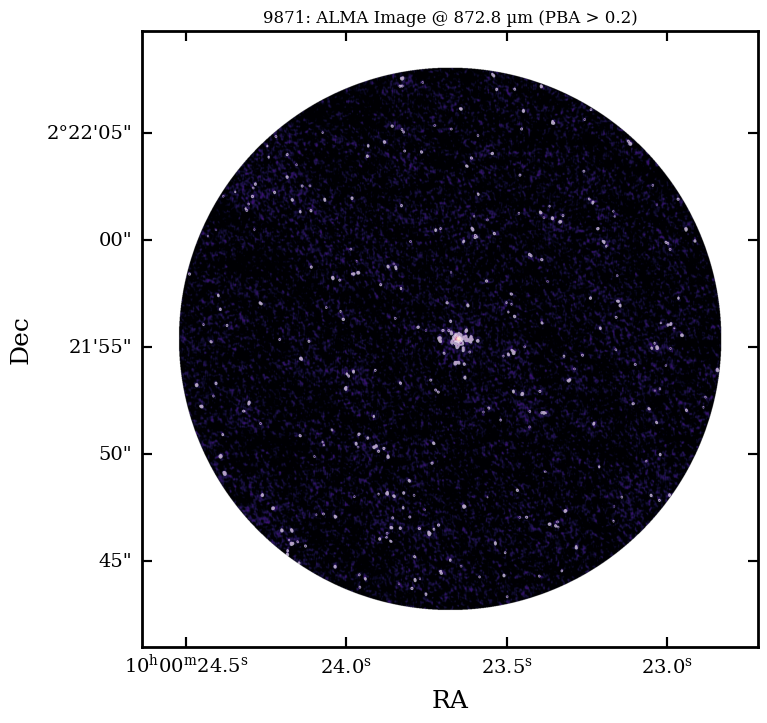

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.0872804167 2.396043055556
CRPIX : 181.0 181.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -2.222222222222e-05 2.222222222222e-05
NAXIS : 360  360


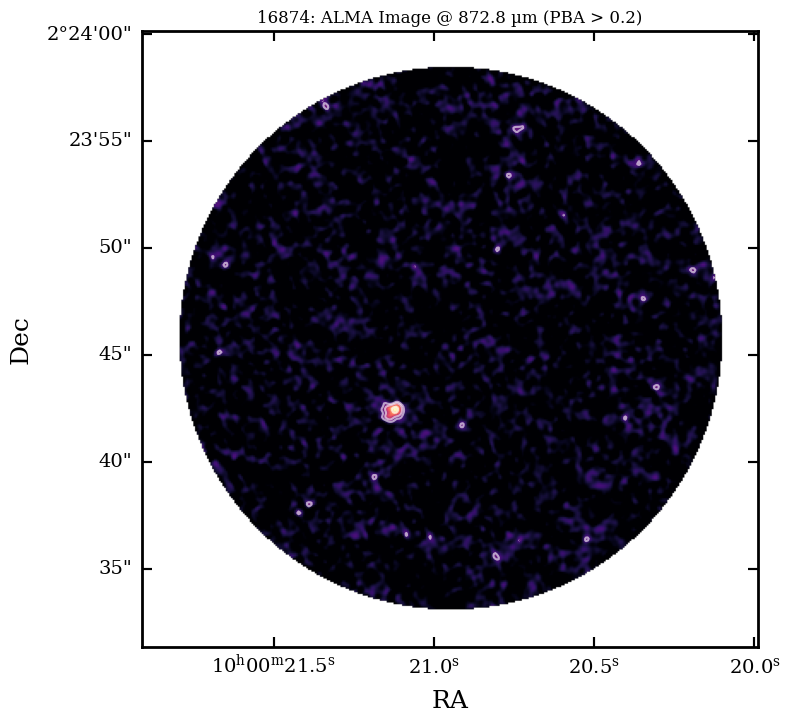

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.0865020833 2.264316666667
CRPIX : 145.0 145.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -4.166666666667e-05 4.166666666667e-05
NAXIS : 288  288


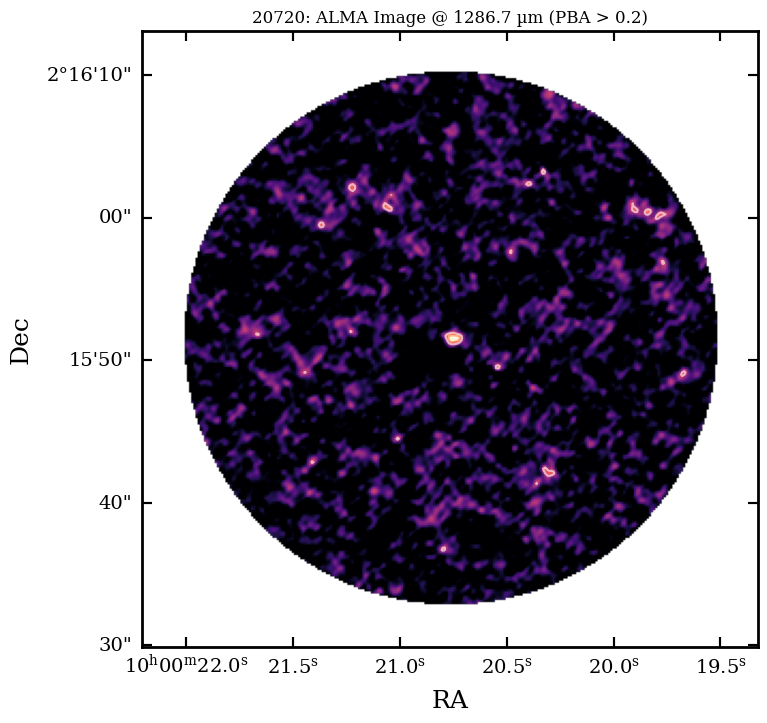

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.1058333333 2.313222222222
CRPIX : 113.0 113.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -3.611111111111e-05 3.611111111111e-05
NAXIS : 224  224


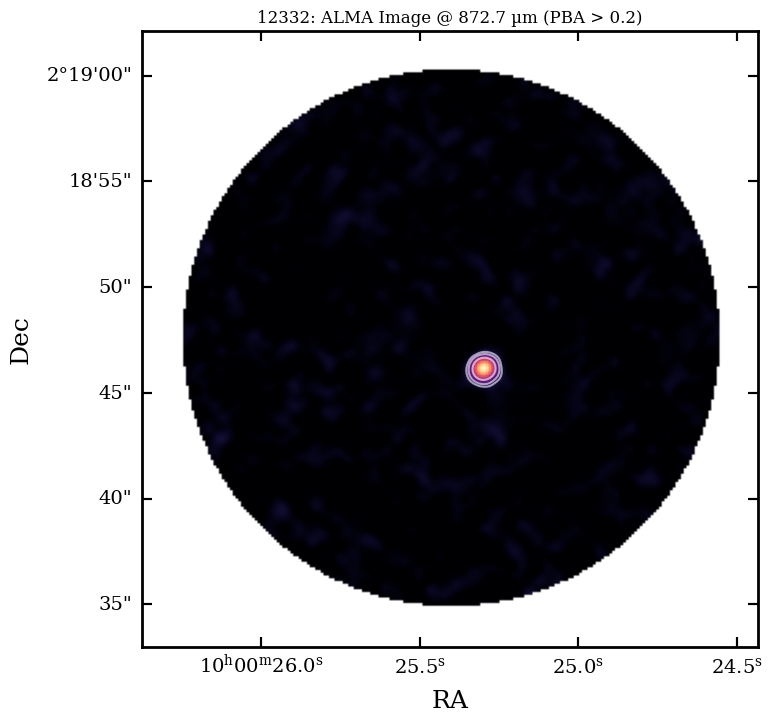

In [36]:
# Define URL_PREFIX for accessing continuum images

for row in sky_matched:
    file = f"./data/cont_images/{row['Image_file']}"
    id = row['ID_3DHST']
    wavelength = row['Obs_wavelength']

#file = f"./data/cont_images/{sky_matched['Image_file'][-1]}"

    with fits.open(file) as hdul:
        # Drop Frequency and Polarisation
        wcs = WCS(hdul[0].header).celestial # Convert WCS to celestial coordinates only! 
        print(f"WCS info: {wcs}")

        # Extract the correct continuum data
        data = hdul[0].data[0, 0, :, :]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection=wcs)

    # Display the continuum image
    im = ax.imshow(data, origin='lower', cmap='magma', vmin=0)

    # Add contours to make the structure pop
    # Levels based on RMS noise (e.g., 3*rms, 5*rms, 7*rms)
    rms = np.nanstd(data)
    ax.contour(data, levels=[3*rms, 5*rms, 10*rms], colors='white', alpha=0.6)

    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.title(f'{id}: ALMA Image @ {wavelength:.1f} µm (PBA > 0.2)')
    plt.savefig(f'plots/{id}_alma_contours.png', dpi=300, bbox_inches='tight')
    plt.show()
    

# Okay next we overplot the contours on the NIRCam cutouts to check the alignment!

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.09865 2.36538
CRPIX : 1030.0 1030.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -3.888888888889e-06 3.888888888889e-06
NAXIS : 2058  2058
File 9871 header says center is: 150.13, 2.3325
File 9871 header says center is: 150.0985353, 2.3653718
ALMA Center: [150.09865   2.36538]
NIRCam Center: [150.0985353   2.3653718]


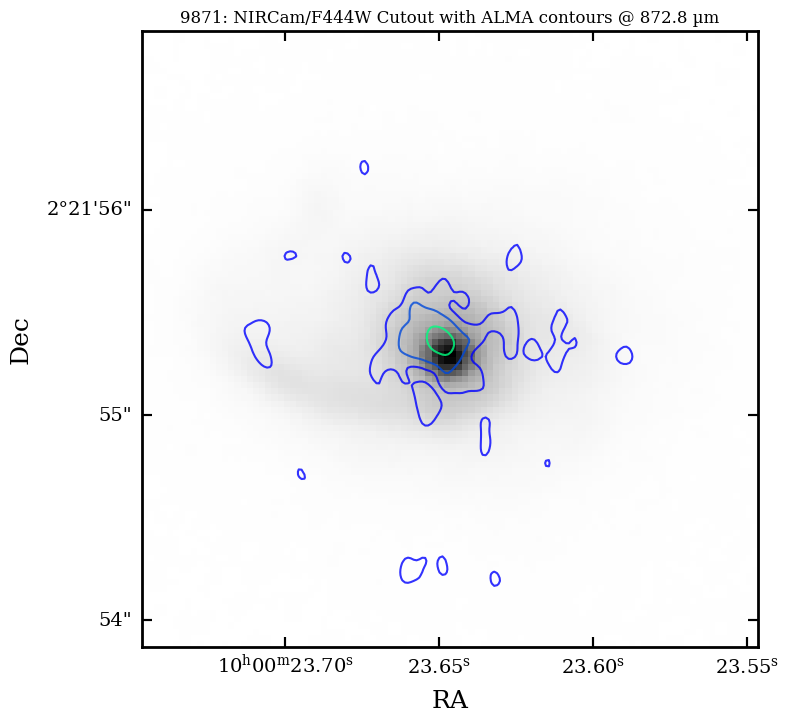

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.0872804167 2.396043055556
CRPIX : 181.0 181.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -2.222222222222e-05 2.222222222222e-05
NAXIS : 360  360
File 16874 header says center is: 150.13, 2.3325
File 16874 header says center is: 150.0880263, 2.3951005
ALMA Center: [150.08728042   2.39604306]
NIRCam Center: [150.0880263   2.3951005]


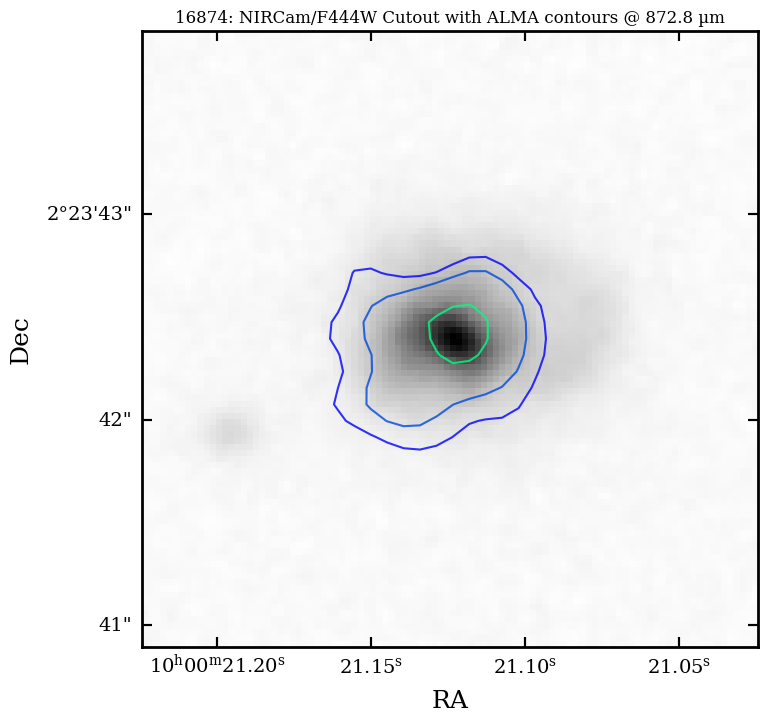

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.0865020833 2.264316666667
CRPIX : 145.0 145.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -4.166666666667e-05 4.166666666667e-05
NAXIS : 288  288
File 20720 header says center is: 150.13, 2.3325
File 20720 header says center is: 150.0864431, 2.2643185
ALMA Center: [150.08650208   2.26431667]
NIRCam Center: [150.0864431   2.2643185]


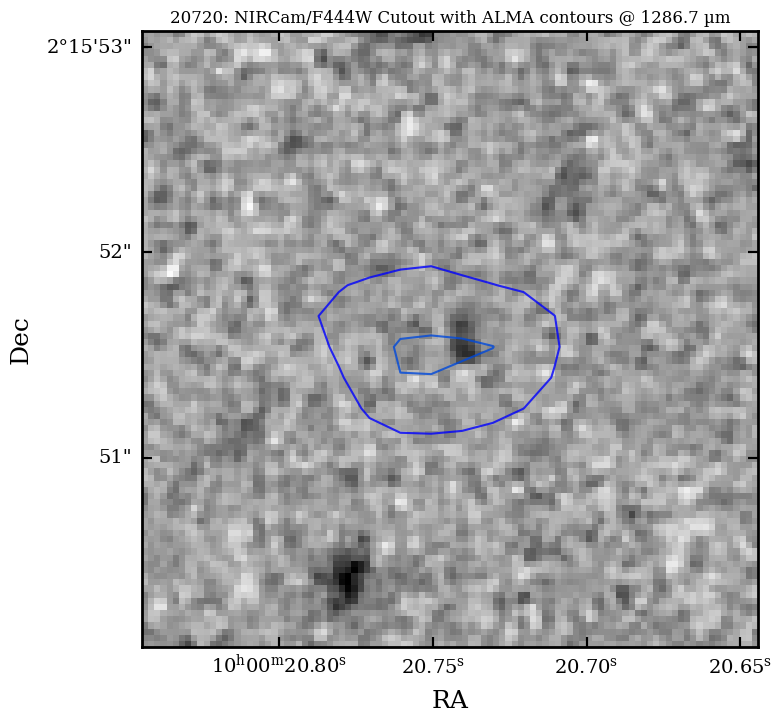

WCS info: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN'
CUNIT : 'deg' 'deg'
CRVAL : 150.1058333333 2.313222222222
CRPIX : 113.0 113.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -3.611111111111e-05 3.611111111111e-05
NAXIS : 224  224
File 12332 header says center is: 150.13, 2.3325
File 12332 header says center is: 150.1054047, 2.3128168
ALMA Center: [150.10583333   2.31322222]
NIRCam Center: [150.1054047   2.3128168]


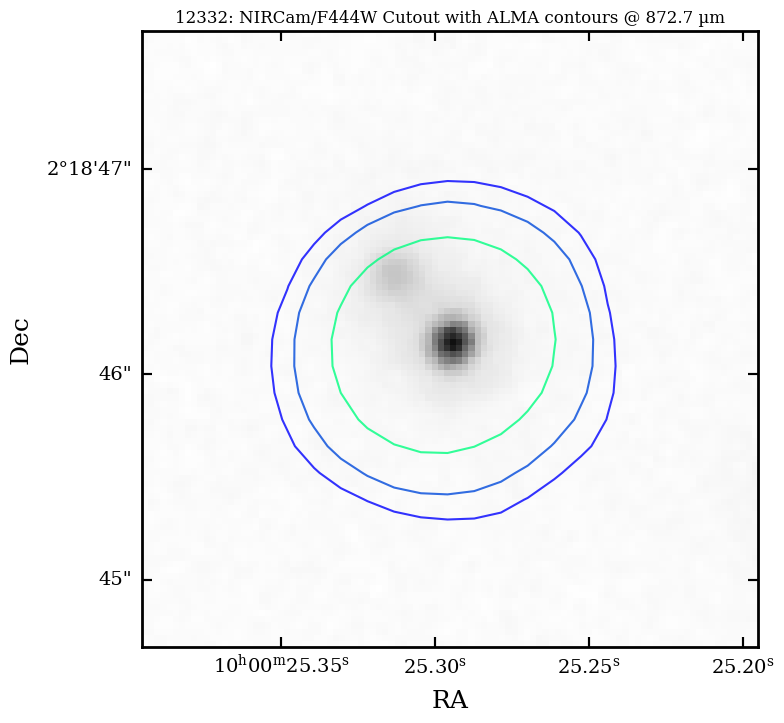

In [48]:
# Load the Blue Jay source catalogue
from email import header


bluejay_path = 'data/catalogues/cat_targets.fits'
my_cat = fits.open(bluejay_path)[1].data
my_cat = Table(my_cat)

for row in sky_matched:
    alma_file = f"./data/cont_images/{row['Image_file']}"
    id = row['ID_3DHST']
    nircam_file = f"./data/F444W_cutouts/{id}_F444W_cutout.fits"
    
    nircam_ra = my_cat[my_cat['id'] == id]['ra'][0]
    nircam_dec = my_cat[my_cat['id'] == id]['dec'][0]
    
    wavelength = row['Obs_wavelength']

    with fits.open(alma_file) as hdul_alma, fits.open(nircam_file) as hdul_nircam:
        # Drop Frequency and Polarisation
        wcs_alma = WCS(hdul_alma[0].header).celestial # Convert WCS to celestial coordinates only! 
        print(f"WCS info: {wcs_alma}")

        # Extract the correct continuum data
        alma_data = hdul_alma[0].data[0, 0, :, :]
        
        header_nircam = hdul_nircam['SCI'].header
        print(f"File {id} header says center is: {header_nircam['CRVAL1']}, {header_nircam['CRVAL2']}")
        
        header_nircam['CRVAL1'] = row['RA']
        header_nircam['CRVAL2'] = row['Dec']
        
        nircam_data = hdul_nircam['SCI'].data
        
        header_nircam['CRPIX1'] = nircam_data.shape[1] / 2.0
        header_nircam['CRPIX2'] = nircam_data.shape[0] / 2.0
        
        print(f"File {id} header says center is: {header_nircam['CRVAL1']}, {header_nircam['CRVAL2']}")
        wcs_nircam = WCS(header_nircam, naxis=2)
        
    print(f"ALMA Center: {wcs_alma.wcs.crval}")
    print(f"NIRCam Center: {wcs_nircam.wcs.crval}")

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection=wcs_nircam)

    # Display the continuum image
    im = ax.imshow(nircam_data, origin='lower', cmap='gray_r')

    # Add contours to make the structure pop
    # Levels based on RMS noise (e.g., 3*rms, 5*rms, 7*rms)
    rms = np.nanstd(alma_data)
    ax.contour(alma_data, 
               transform=ax.get_transform(wcs_alma), 
               levels=[3*rms, 5*rms, 10*rms], 
               cmap='winter', alpha=0.8)
    
    # 1. Define the center of your cutout in pixels
    center_y, center_x = nircam_data.shape[0] / 2, nircam_data.shape[1] / 2
    
    # 2. Define a "zoom" box (e.g., 50 pixels in each direction)
    zoom = 50 
    
    # 3. Apply the limits to the axes
    ax.set_xlim(center_x - zoom, center_x + zoom)
    ax.set_ylim(center_y - zoom, center_y + zoom)

    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.title(f'{id}: NIRCam/F444W Cutout with ALMA contours @ {wavelength:.1f} µm')
    plt.savefig(f'plots/{id}_nircam_with_cont.png', dpi=300, bbox_inches='tight')
    plt.show()
    

In [27]:
from astropy.io import fits
from astroquery.alma import Alma
from astropy.coordinates import SkyCoord
from astropy.table import Table, join, hstack
import astropy.units as u
import numpy as np
from astropy.time import Time

# When A3COSMOS was published
cut_off = Time('2025-03-12')

# Initialise the ALMA service
alma = Alma()

# Load the Blue Jay source catalogue
bluejay_path = 'cat_targets.fits'
my_cat = fits.open(bluejay_path)[1].data
my_cat = Table(my_cat)

# Rename columns for cross-matching
my_cat.rename_column('id', 'ID')
my_cat.rename_column('ra', 'RA')
my_cat.rename_column('dec', 'Dec')

# Keep only the IDs of galaxies that have MIRI photometry
miri_path = '/Users/benjamincollins/University/master/Red_Cardinal/photometry/phot_tables/fits/Phot_Table_MIRI.fits'

miri_table = Table.read(miri_path, format='fits')
galaxy_ids = miri_table['ID']

# Filter out Blue Jay galaxies that are not in the MIRI table
source_cat_miri = my_cat[np.isin(my_cat['ID'], galaxy_ids)]

my_galaxies = source_cat_miri['ID', 'RA', 'Dec']

my_galaxies = Table()
my_galaxies['id'] = my_cat['ID']
my_galaxies['ra'] = my_cat['RA']*u.deg # Explicitly ensure units
my_galaxies['dec'] = my_cat['Dec']*u.deg

# We join 'ivoa.obscore' (the master ALMA table) with your 'TAP_UPLOAD.my_targets'
query = """
SELECT oc.*, mt.id 
FROM ivoa.obscore AS oc 
JOIN TAP_UPLOAD.my_targets AS mt 
ON CONTAINS(POINT('ICRS', oc.s_ra, oc.s_dec), CIRCLE('ICRS', mt.ra, mt.dec, 0.016)) = 1
"""

alma = Alma()
result = alma.query_tap(query, uploads={'my_targets': my_galaxies})

print(result)
x
projects_found = {}

for row in source_cat_miri:
    id = row['ID']
    ra = row['RA']
    dec = row['Dec']

    print("Querying ALMA for galaxy ID:", id, "at RA:", ra, "Dec:", dec)
    galaxy_coord = SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')

    # Perform a region-based query
    # Searching for any ALMA observations that cover this position (within a 1 arcminute radius)
    result = alma.query_region(galaxy_coord, radius=1*u.arcmin)
    
    time.sleep(1)
    
    # Get valid science data
    science_data = result[result['science_observation'] == True]
    valid_data = science_data[science_data['qa2_passed'] == True]
    
    # Filter useful columns
    audit_table = valid_data['proposal_id', 'obs_release_date', 'obs_id']    
    
    if len(audit_table) == 0:
        print(" ❌ No valid ALMA observations found for this galaxy.")
        continue
    
    # Convert release_date to astropy Time objects for easy comparison
    release_dates = Time(audit_table['obs_release_date'])
    new_data_mask = release_dates > cut_off

    new_proposals = audit_table[new_data_mask]
    
    unique_ids = np.unique(new_proposals['proposal_id'])
    
    projects_found[id] = unique_ids
    
    print(f" ✅ Found {len(unique_ids)} new ALMA project(s) for galaxy ID {id}: {unique_ids}")


DALServiceError: 502 Server Error: Proxy Error for url: https://almascience.nrao.edu/tap/sync/yonysbunbbtoz4gd/run

In [15]:
print(result.columns)
print(result['member_ous_uid'], result['obs_title'], result['publication_year'])


obs_id = result[result['publication_year'] > 2024]
obs_id = obs_id['obs_release_date']
print(obs_id)


<TableColumns names=('pol_states','obs_publisher_did','obs_collection','facility_name','instrument_name','obs_id','dataproduct_type','calib_level','collections','target_name','s_ra','s_dec','s_fov','s_region','s_xel1','s_xel2','em_xel','t_xel','pol_xel','s_resolution','t_min','t_max','t_exptime','t_resolution','em_min','em_max','em_res_power','sensitivity_10kms','cont_sensitivity_bandwidth','pwv','group_ous_uid','member_ous_uid','asdm_uid','obs_title','type','scan_intent','science_observation','spatial_scale_max','qa2_passed','bib_reference','science_keyword','scientific_category','pi_userid','pi_name','spectral_resolution','lastModified','o_ucd','access_url','access_format','access_estsize','proposal_id','data_rights','gal_longitude','gal_latitude','band_list','em_resolution','bandwidth','antenna_arrays','is_mosaic','obs_release_date','spatial_resolution','frequency_support','frequency','velocity_resolution','obs_creator_name','pub_title','first_author','authors','pub_abstract','publi